**Task:**

* Use classical NLP
techniques to classify whether a given message/text is **Real or Fake
Message.**

* Use Bag of n-grams to preprocess the next and apply different classification algorithms.

* Scikit-learn CountVectorizert.


Credits: https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("/content/Fake_Real_Data.csv")

print("dataset shape:", df.shape)
df.head()

dataset shape: (9900, 2)


,Text,label
0,Top Trump Surrogate BRUTALLY Stabs Him In The...,Fake
1,U.S. conservative leader optimistic of common ...,Real
2,"Trump proposes U.S. tax overhaul, stirs concer...",Real
3,Court Forces Ohio To Allow Millions Of Illega...,Fake
4,Democrats say Trump agrees to work on immigrat...,Real


In [3]:
# check distribution of labels

df.label.value_counts()

,count
label,
Fake,5000
Real,4900


In [4]:
#Add the new column "label_num" which gives a unique number to each of these labels
df['label_num'] = df.label.map({'Real': 1, 'Fake': 0})
df.head()

,Text,label,label_num
0,Top Trump Surrogate BRUTALLY Stabs Him In The...,Fake,0
1,U.S. conservative leader optimistic of common ...,Real,1
2,"Trump proposes U.S. tax overhaul, stirs concer...",Real,1
3,Court Forces Ohio To Allow Millions Of Illega...,Fake,0
4,Democrats say Trump agrees to work on immigrat...,Real,1


Modelling without preprocess Text data

In [5]:
from sklearn.model_selection import train_test_split

# Do the "train-test" splitting with test size of 20% with random state of 2022 and stratify sampling too
X_train, X_test, y_train, y_test = train_test_split(
    df.Text, # Changed to df.Text for features
    df.label_num,
    test_size=0.2,
    random_state=2022,
    stratify=df.label_num,
)
print("Shape of X_train is:", X_train.shape)
print("\nShape of X_test is:", X_test.shape)

Shape of X_train is: (7920,)

Shape of X_test is: (1980,)


Use scikit-learn pipeline module to create a classification pipeline to classify the data.

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.feature_extraction.text import CountVectorizer # Corrected import
from sklearn.neighbors import KNeighborsClassifier

# create a pipeline object
clf = Pipeline([
    ("Count-vetorzer", CountVectorizer()), # Corrected class name
    ("KNN", KNeighborsClassifier())
])

# fit with X_train and y_train
clf.fit(X_train, y_train)

# get the predictions for X_test and store it in y_pred
y_pred = clf.predict(X_test)

# print the classfication report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.92      0.94      1000
           1       0.93      0.97      0.95       980

    accuracy                           0.94      1980
   macro avg       0.95      0.95      0.94      1980
weighted avg       0.95      0.94      0.94      1980



**Use:**
* CountVectorizer with only trigrams.
* RandomForest as the classifier
* Print the classification report

In [7]:
from sklearn.ensemble import RandomForestClassifier
# create a pipeline object
clf = Pipeline([
    ("Count-vetorzer", CountVectorizer(ngram_range=(3,3))), # Corrected class name
    ("RF", RandomForestClassifier())
])

# fit with X_train and y_train
clf.fit(X_train, y_train)

# get the predictions for X_test and store it y_pred
y_pred = clf.predict(X_test)


# print the classfication report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1000
           1       0.99      1.00      0.99       980

    accuracy                           0.99      1980
   macro avg       0.99      0.99      0.99      1980
weighted avg       0.99      0.99      0.99      1980



**Use:**
* CountVectorizer with both unigram and bigrams.
* Multinomial Naive Bayes as the classifier with

In [8]:
from sklearn.naive_bayes import MultinomialNB
# create a pipeline object
clf = Pipeline([
    ("Count-vetorzer", CountVectorizer(ngram_range=(1,2))), # Corrected class name
    ("MNB", MultinomialNB())
])

# fit with X_train and y_train
clf.fit(X_train, y_train)

# get the predictions for X_test and store it in y_pred
y_pred = clf.predict(X_test)

# print the classfication report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1000
           1       0.99      0.98      0.99       980

    accuracy                           0.99      1980
   macro avg       0.99      0.99      0.99      1980
weighted avg       0.99      0.99      0.99      1980



**Use:**
* CountVectorizer with unigram, Bigram, and trigrams
* RandomForest as the classifier.
* print a classification report

In [10]:
# create a pipeline object
clf = Pipeline([
    ("count-vectorizer", CountVectorizer()),
    ("RF", RandomForestClassifier())
])

# fit with X_train and y_train
clf.fit(X_train, y_train)

# get the predictions for X_test and store it in y_pred
y_pred = clf.predict(X_test)

# print the classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1000
           1       1.00      1.00      1.00       980

    accuracy                           1.00      1980
   macro avg       1.00      1.00      1.00      1980
weighted avg       1.00      1.00      1.00      1980



[[998   2]
 [  2 978]]


Text(95.72222222222221, 0.5, 'Truth')

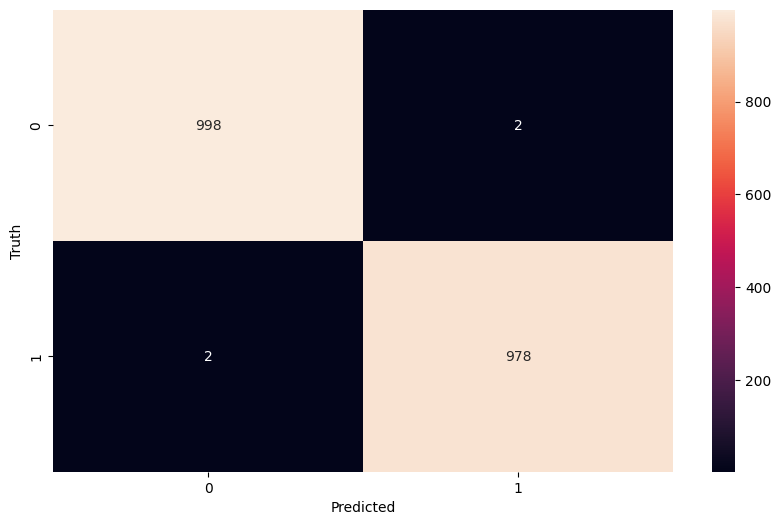

In [13]:
# Pirnt the confusion matrix for the best model
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')